# 03 Grid Extension

In [15]:
import torch
from kan import KAN, create_dataset
import matplotlib.pyplot as plt

In [16]:
f = lambda x: torch.exp(torch.sin(torch.pi*x[:,[0]]) + x[:,[1]]**2)
dataset = create_dataset(f, n_var=2, train_num=1000, test_num=1000, ranges=[-1, 1])

## Train with a small grid (grid=3)

In [17]:
model = KAN(width=[2, 5, 1], grid=3, k=3, seed=42, auto_save=False)
results_g3 = model.fit(dataset, opt="LBFGS", steps=30, lr=1.0, lamb=0.001)
print(f"Grid 3 - final test RMSE: {results_g3['test_loss'][-1]:.6f}")

| train_loss: 1.80e-02 | test_loss: 1.87e-02 | reg: 7.48e+00 | : 100%|█| 30/30 [00:04<00:00,  6.45it

Grid 3 - final test RMSE: 0.018726


## Extend the grid to higher resolutions

In [18]:
all_test_losses = list(results_g3["test_loss"])
refinement_points = []

for new_grid in [5, 10, 20, 30, 50, 100]:
    model = model.refine(new_grid)
    refinement_points.append(len(all_test_losses))
    res = model.fit(dataset, opt="LBFGS", steps=30, lr=1.0, lamb=0.001)
    all_test_losses.extend(res["test_loss"])
    print(f"Grid {new_grid:2d} - final test RMSE: {res['test_loss'][-1]:.6f}")

| train_loss: 1.35e-02 | test_loss: 1.35e-02 | reg: 7.41e+00 | : 100%|█| 30/30 [00:03<00:00,  9.98it


saving model version 0.2
Grid  5 - final test RMSE: 0.013531
saving model version 0.3


| train_loss: 1.35e-02 | test_loss: 1.35e-02 | reg: 7.41e+00 | : 100%|█| 30/30 [00:03<00:00,  9.37it


saving model version 0.4
Grid 10 - final test RMSE: 0.013531
saving model version 0.5


| train_loss: 1.35e-02 | test_loss: 1.35e-02 | reg: 7.42e+00 | : 100%|█| 30/30 [00:01<00:00, 26.91it


...

saving model version 0.8
Grid 30 - final test RMSE: 0.013536
saving model version 0.9


| train_loss: 2.53e-03 | test_loss: 3.22e-03 | reg: 6.98e+00 | : 100%|█| 30/30 [00:07<00:00,  4.03it


saving model version 0.10
Grid 50 - final test RMSE: 0.003216
saving model version 0.11


| train_loss: 2.02e-03 | test_loss: 6.84e-03 | reg: 6.97e+00 | : 100%|█| 30/30 [00:06<00:00,  4.57it

saving model version 0.12
Grid 100 - final test RMSE: 0.006843


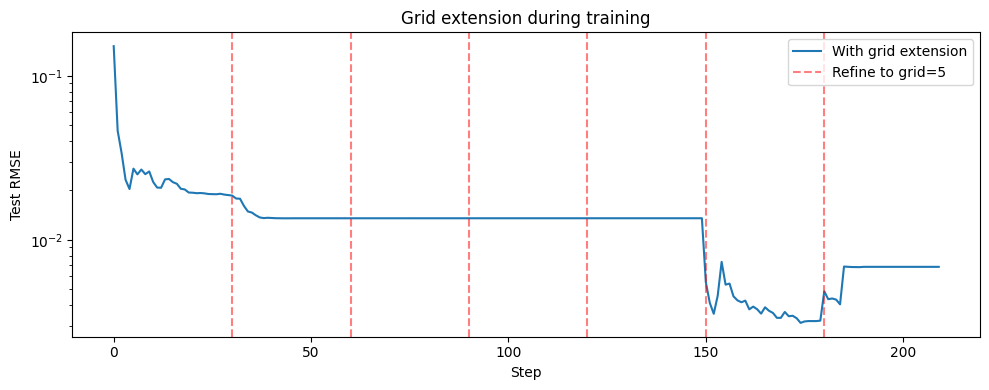

In [19]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(all_test_losses, label="With grid extension")
for i, rp in enumerate(refinement_points):
    ax.axvline(rp, color="red", linestyle="--", alpha=0.5,
               label=f"Refine to grid={[5,10,20][i]}" if i == 0 else None)
ax.set_xlabel("Step")
ax.set_ylabel("Test RMSE")
ax.set_yscale("log")
ax.legend()
ax.set_title("Grid extension during training")
plt.tight_layout()
plt.show()

## Compare: grid extension vs training from scratch

| train_loss: 3.50e-02 | test_loss: 8.42e-02 | reg: 1.43e+01 | : 100%|█| 120/120 [00:17<00:00,  6.70


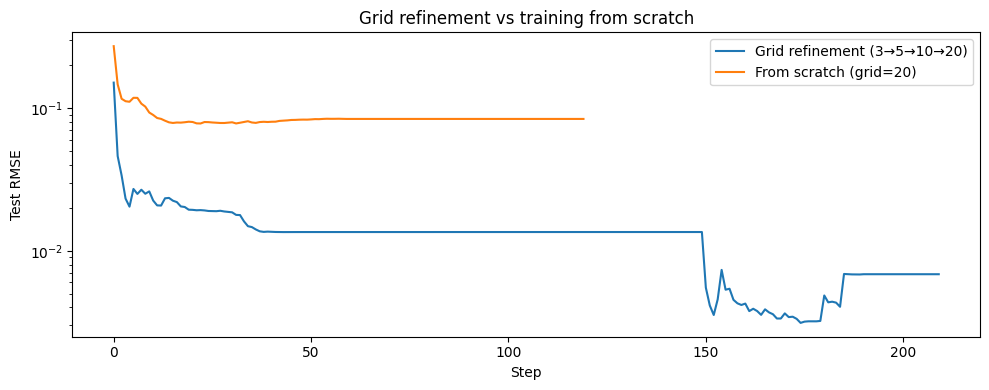

In [20]:
model_scratch = KAN(width=[2, 5, 1], grid=20, k=3, seed=42, auto_save=False)
results_scratch = model_scratch.fit(dataset, opt="LBFGS", steps=120, lr=1.0, lamb=0.001)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(all_test_losses, label="Grid refinement (3→5→10→20)")
ax.plot(results_scratch["test_loss"], label="From scratch (grid=20)")
ax.set_xlabel("Step")
ax.set_ylabel("Test RMSE")
ax.set_yscale("log")
ax.legend()
ax.set_title("Grid refinement vs training from scratch")
plt.tight_layout()
plt.show()

## Pruning

Before pruning:
saving model version 0.13

After pruning:


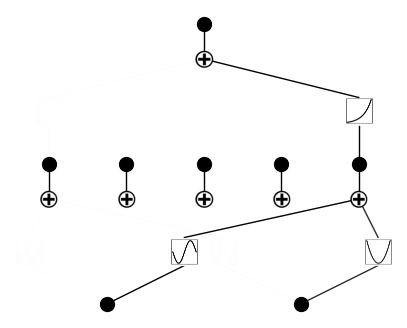

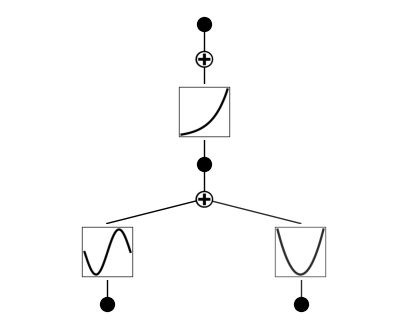

In [21]:
print("Before pruning:")
model.plot()

model_pruned = model.prune()
print("\nAfter pruning:")
model_pruned.plot()